#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.calibration import intercept_recalibration, PDCalibrator
from src.feature_engineering import create_target_def12
from src.metrics import my_metrics, my_threshold_metrics
from src.modelling import apply_pipe
from src.plots import my_calibration, my_calibration_comparison
from src.preprocessing import my_input_load, my_time_split

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# Pipeline import

import joblib
pipeline_09 = joblib.load("../models/PIPELINE_ver_011_cal_none.pkl")
pipeline_10 = joblib.load("../models/PIPELINE_ver_011_cal_shift-test.pkl")

In [4]:
# load input file

this_dataset = my_input_load(2016, 2021)
#this_dataset.info(show_counts=True, verbose=True)

In [5]:
# CREATE TARGET VARIABLE

this_dataset, dr_summary = create_target_def12(this_dataset)

LoanDate range:     2016-01-01 00:00:00 2021-12-31 00:00:00
+12 months:         2017-01-01 00:00:00 2022-12-31 00:00:00
DefaultDate range:  2016-04-29 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066
2019,28487,4879,0.171271
2020,19959,2294,0.114936
2021,30266,3694,0.122051


In [6]:
# SPLIT TRAIN/TEST/OOT

windows = {"train": (2016, 2018), "test":  (2019, 2020), "toot":  (2021, 2021)}

splits = my_time_split(this_dataset, "LoanYear", windows)

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]
X_toot = splits["toot"]["X"]
y_toot = splits["toot"]["y"]

# SPLIT 5 YEARS, 2 YEARS, 1 YEARS

windows = {"long": (2016, 2020), "middle":  (2019, 2020), "short":  (2020, 2020)}

splits = my_time_split(this_dataset, "LoanYear", windows)

X_test_2016_2020 = splits["long"]["X"]
y_test_2016_2020 = splits["long"]["y"]
X_test_2019_2020 = splits["middle"]["X"]
y_test_2019_2020 = splits["middle"]["y"]
X_test_2020_2020 = splits["short"]["X"]
y_test_2020_2020 = splits["short"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2016 - 2018
Shape (X, y) : (34078, 105), (34078,)

LoanYear distribution
LoanYear
2016     6023
2017    11109
2018    16946
Name: count, dtype: int64

Default rate : 0.1935
------------------------------------------------------------

TEST
Years        : 2019 - 2020
Shape (X, y) : (48446, 105), (48446,)

LoanYear distribution
LoanYear
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1481
------------------------------------------------------------

TOOT
Years        : 2021 - 2021
Shape (X, y) : (30266, 105), (30266,)

LoanYear distribution
LoanYear
2021    30266
Name: count, dtype: int64

Default rate : 0.1221
------------------------------------------------------------

SPLIT SUMMARY

LONG
Years        : 2016 - 2020
Shape (X, y) : (82524, 105), (82524,)

LoanYear distribution
LoanYear
2016     6023
2017    11109
2018    16946
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1668
------------------------

# Runs on various calibration windows

#### runs 

Run name: 2020_2020
EmploymentStatus: replacing 19,959 values of -1 with NaN
MaritalStatus: replacing 19,959 values of -1 with NaN
OccupationArea: replacing 19,959 values of -1 with NaN
UseOfLoan: replacing 19,959 values of -1 with NaN
Intercept shift (delta): -0.681076

***** BEFORE CALIBRATION *****
Education: replacing 3 values of -1 with NaN
EmploymentStatus: replacing 30,266 values of -1 with NaN
MaritalStatus: replacing 30,266 values of -1 with NaN
OccupationArea: replacing 30,266 values of -1 with NaN
UseOfLoan: replacing 30,266 values of -1 with NaN


prob_bin,Count,Defaults,Avg_PD,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.044035,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.083473,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.127562,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.174427,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.223301,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.272519,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.323126,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.372183,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.441142,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.534179,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------
----------------------------------------
OOT (2020_2020)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 21.08%
Brier       : 0.1101
Exposure    : 85,557,401
EL Total    : 11,192,523
EL Rate     : 13.08%
----------------------------------------

***** AFTER CALIBRATION *****


prob_bin,Count,Defaults,Avg_PD,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",1395,18,0.041074,0.012903,0.003022,0.006981,0.018826,0.046091
"(0.05, 0.1]",11889,819,0.077522,0.068887,0.002323,0.064335,0.073440,0.392817
"(0.1, 0.15]",9673,1231,0.122153,0.127261,0.003389,0.120620,0.133903,0.319600
"(0.15, 0.2]",4028,720,0.171239,0.178749,0.006037,0.166916,0.190581,0.133087
"(0.2, 0.25]",1807,428,0.221034,0.236857,0.010002,0.217254,0.256460,0.059704
"(0.25, 0.3]",835,225,0.271709,0.269461,0.015354,0.239367,0.299555,0.027589
"(0.3, 0.35]",410,151,0.323119,0.368293,0.023821,0.321603,0.414982,0.013547
"(0.35, 0.4]",142,55,0.370129,0.387324,0.040880,0.307200,0.467448,0.004692
"(0.4, 0.5]",80,43,0.431188,0.537500,0.055744,0.428241,0.646759,0.002643
"(0.5, 0.6]",7,4,0.543470,0.571429,0.187044,0.204823,0.938035,0.000231


----------------------------------------
----------------------------------------
OOT (2020_2020)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 12.22%
Brier       : 0.1019
Exposure    : 85,557,401
EL Total    : 6,609,820
EL Rate     : 7.73%
----------------------------------------
Run name: 2019_2020
EmploymentStatus: replacing 48,446 values of -1 with NaN
MaritalStatus: replacing 48,446 values of -1 with NaN
OccupationArea: replacing 48,446 values of -1 with NaN
UseOfLoan: replacing 48,446 values of -1 with NaN
Intercept shift (delta): -0.383305

***** BEFORE CALIBRATION *****
Education: replacing 3 values of -1 with NaN
EmploymentStatus: replacing 30,266 values of -1 with NaN
MaritalStatus: replacing 30,266 values of -1 with NaN
OccupationArea: replacing 30,266 values of -1 with NaN
UseOfLoan: replacing 30,266 values of -1 with NaN


...

----------------------------------------
----------------------------------------
OOT (2019_2020)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 15.64%
Brier       : 0.1030
Exposure    : 85,557,401
EL Total    : 8,394,183
EL Rate     : 9.81%
----------------------------------------
Run name: 2016_2020
Education: replacing 2 values of -1 with NaN
EmploymentStatus: replacing 72,715 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 72,715 values of -1 with NaN
OccupationArea: replacing 72,715 values of -1 with NaN
UseOfLoan: replacing 72,715 values of -1 with NaN
Intercept shift (delta): -0.216984

***** BEFORE CALIBRATION *****
Education: replacing 3 values of -1 with NaN
EmploymentStatus: replacing 30,266 values of -1 with NaN
MaritalStatus: replacing 30,266 values of -1 with NaN
OccupationArea: replacing 30,266 values of -1 with NaN
UseOfLoan: replacing 30,266 values

prob_bin,Count,Defaults,Avg_PD,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.044035,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.083473,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.127562,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.174427,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.223301,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.272519,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.323126,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.372183,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.441142,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.534179,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------
----------------------------------------
OOT (2016_2020)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 21.08%
Brier       : 0.1101
Exposure    : 85,557,401
EL Total    : 11,192,523
EL Rate     : 13.08%
----------------------------------------

***** AFTER CALIBRATION *****


prob_bin,Count,Defaults,Avg_PD,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",167,0,0.043145,0.000000,0.000000,0.000000,0.000000,0.005518
"(0.05, 0.1]",3955,138,0.082751,0.034893,0.002918,0.029173,0.040612,0.130675
"(0.1, 0.15]",9133,696,0.125922,0.076207,0.002776,0.070765,0.081649,0.301758
"(0.15, 0.2]",7649,914,0.173345,0.119493,0.003709,0.112223,0.126762,0.252726
"(0.2, 0.25]",4355,704,0.222092,0.161653,0.005578,0.150720,0.172587,0.143891
"(0.25, 0.3]",2337,479,0.272459,0.204964,0.008350,0.188597,0.221330,0.077215
"(0.3, 0.35]",1255,301,0.321878,0.239841,0.012053,0.216217,0.263464,0.041466
"(0.35, 0.4]",731,198,0.372397,0.270862,0.016437,0.238645,0.303078,0.024153
"(0.4, 0.5]",574,208,0.438899,0.362369,0.020063,0.323045,0.401694,0.018965
"(0.5, 0.6]",99,49,0.534860,0.494949,0.050249,0.396461,0.593438,0.003271


----------------------------------------
----------------------------------------
OOT (2016_2020)
----------------------------------------
AUC         : 0.6814
KS          : 0.2598
Observed DR : 12.21%
Mean PD     : 17.85%
Brier       : 0.1051
Exposure    : 85,557,401
EL Total    : 9,538,349
EL Rate     : 11.15%
----------------------------------------


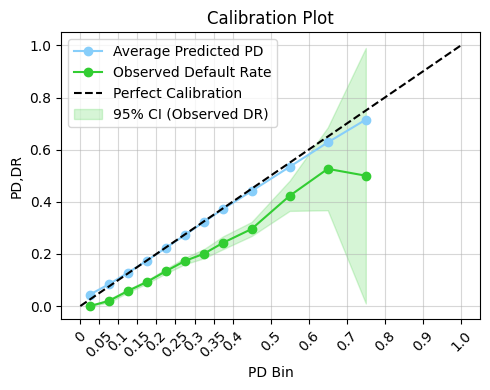

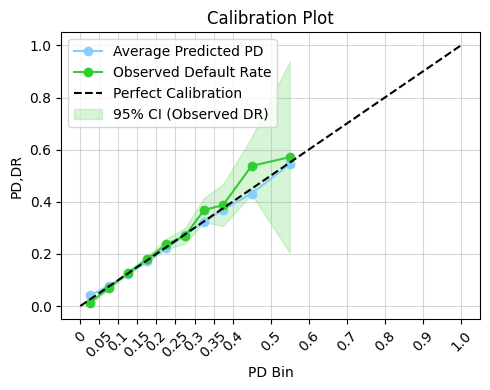

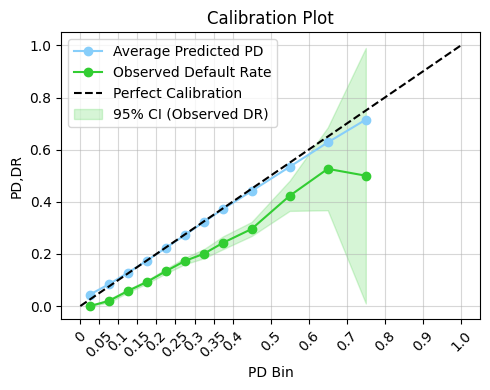

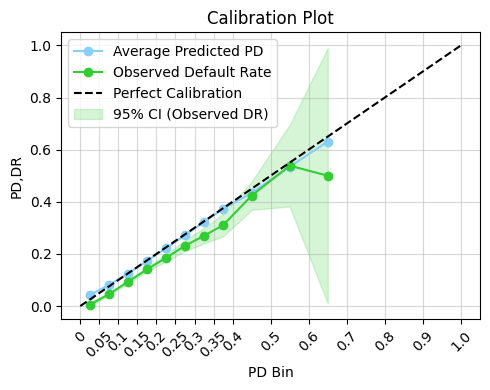

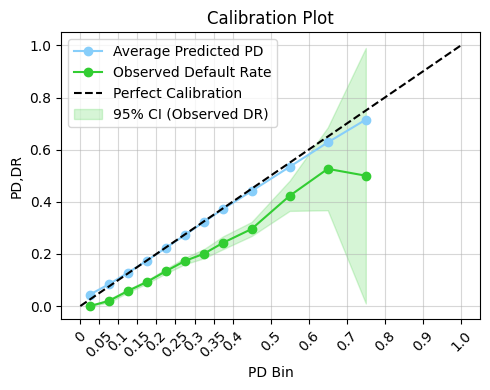

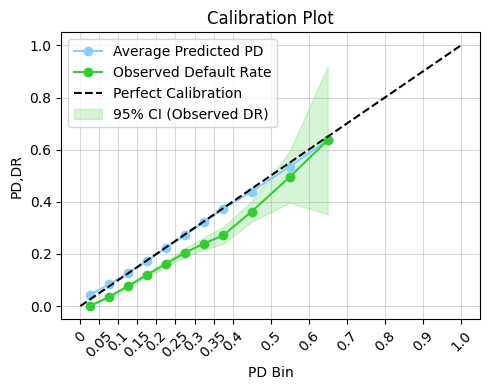

In [8]:
# LOOP ON VARIOUS CALIBRATION WINDOWS
# ----------------------------------------------------------
# each loop-step trains calibration on a predefined window
# and predicts/calibrates the oot sample 
# ----------------------------------------------------------
# calibration method: 'intercept_shift_test' "shift"  
#    2020-2020 Intercept shift (delta): -0.6810755371595716  
#    2019-2020 Intercept shift (delta): -0.38330530029264454
#    2016-2020 Intercept shift (delta): -0.21698419702798066

###### setup runs
runs = {
    "2020_2020": {
        "X": test_2020_2020,
        "y": y_test_2020_2020,
    },
    "2019_2020": {
        "X": test_2019_2020,
        "y": y_test_2019_2020,
    },
    "2016_2020": {
        "X": test_2016_2020,
        "y": y_test_2016_2020,
    },
}
results = {}

for name, run_data in runs.items():

    print("=" * 70)
    print(f"Run name: {name}")
    print("=" * 70)

    ###################################################
    # calibration training sample
    ###################################################

    predictions_cal   = apply_pipe(run_data["X"], pipeline_09)
    y_pred_cal, delta = intercept_recalibration(run_data["y"], predictions_cal["PD"])
    print(f"Intercept shift (delta): {delta:.6f}")

    ###################################################
    # sample to apply (before calibration)
    ###################################################

    print("\n***** BEFORE CALIBRATION *****")
    
    predictions_oot = apply_pipe(toot, pipeline_09)

    my_calibration(y_toot, predictions_oot["PD"])

    metrics_before = my_metrics(
        y_true=y_toot,
        pd_pred=predictions_oot["PD"],
        exposure=predictions_oot["Amount"],
        el=predictions_oot["EL"],
        dataset_name=f"OOT ({name})",
    )

    ###################################################
    # train calibration
    ###################################################

    calibrator = PDCalibrator(method="shift", shift=delta)
    calibrator.fit(predictions_cal, run_data["y"])

    ###################################################
    # calibrate sample
    ###################################################

    predictions_oot = calibrator.transform(predictions_oot)
    predictions_oot["EL"] = (predictions_oot["PD"] * predictions_oot["Amount"] * predictions_oot["LossGivenDefault"])

    ###################################################
    # sample to apply (after calibration)
    ###################################################

    print("\n***** AFTER CALIBRATION *****")

    my_calibration(y_toot, predictions_oot["PD"])

    metrics_after = my_metrics(
        y_true=y_toot,
        pd_pred=predictions_oot["PD"],
        exposure=predictions_oot["Amount"],
        el=predictions_oot["EL"],
        dataset_name=f"OOT ({name})",
    )

    ###################################################
    # save
    ###################################################

    results[name] = {
        "delta": delta,
        "predictions": predictions_oot.copy(),
        "metrics_before": metrics_before,
        "metrics_after": metrics_after,
    }

#### metrics comparison

In [9]:
# comparison of basic metrics

results_all = pd.DataFrame([
    results["2020_2020"]["metrics_after"],
    results["2019_2020"]["metrics_after"],
    results["2016_2020"]["metrics_after"]
])
display(results_all.style.hide(axis="index"))

# apply PD threshold and compare metrics

my_threshold_metrics(y_toot, results["2020_2020"]["predictions"]["PD"], 0.20, results["2020_2020"]["predictions"]["Amount"], results["2020_2020"]["predictions"]["EL"], dataset_name="OOT 2020_2020", verbose=True)
my_threshold_metrics(y_toot, results["2019_2020"]["predictions"]["PD"], 0.20, results["2019_2020"]["predictions"]["Amount"], results["2019_2020"]["predictions"]["EL"], dataset_name="OOT 2019_2020", verbose=True)
my_threshold_metrics(y_toot, results["2016_2020"]["predictions"]["PD"], 0.20, results["2016_2020"]["predictions"]["Amount"], results["2016_2020"]["predictions"]["EL"], dataset_name="OOT 2016_2020", verbose=True)


Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
OOT (2020_2020),0.681449,0.259812,0.122051,0.122246,0.101923,85557401.031400,6609819.995185,0.077256
OOT (2019_2020),0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
OOT (2016_2020),0.681449,0.259812,0.122051,0.178499,0.105088,85557401.031400,9538349.020827,0.111485



OOT 2020_2020
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            89.16%
Mean PD                           0.1222            0.1056
Exposure                      85,557,401        71,226,233
Mean Exposure                      2,827             2,639
EL                             6,609,820         4,506,906
EL Rate                            7.73%             6.33%
Implied LGD                       63.20%            59.91%
Default Rate                      12.21%            10.33%

OOT 2019_2020
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            78.38%
Mean PD                           0.1564            0.1248
Exposure  

#### plot

prob_bin,Count,Defaults,Avg_PD_1,Avg_PD_2,Avg_PD_3,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.035756,0.030446,0.022786,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.068329,0.058486,0.044104,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.105333,0.090676,0.068956,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.145384,0.125933,0.096661,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.187967,0.163908,0.127088,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.231716,0.203459,0.159447,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.277634,0.245564,0.194668,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.323078,0.287850,0.230871,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.388692,0.350095,0.285870,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.480157,0.438994,0.367685,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------


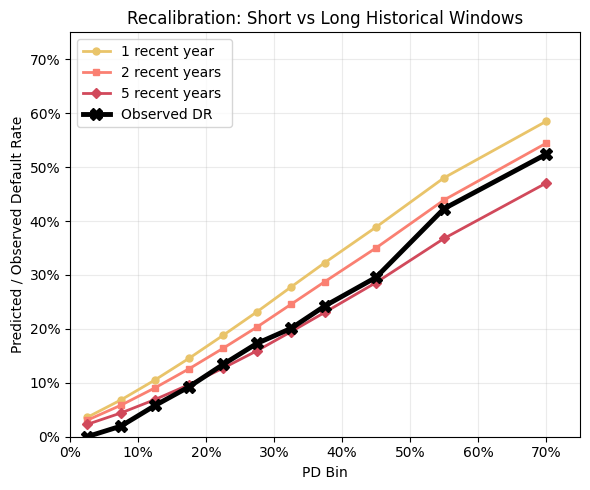

In [ ]:
# compare the 3 calibrations on raw pds

my_calibration_comparison(y_toot,
                          results["2016_2020"]["predictions"]["PD_raw"],
                          results["2016_2020"]["predictions"]["PD"], 
                          results["2019_2020"]["predictions"]["PD"], 
                          results["2020_2020"]["predictions"]["PD"]
                          )

#### W&B integration

In [ ]:
# log to W&B

# import wandb
# wandb.login()

# wandb.init(
#     project="my-credit-risk-model",
#     name="CALIBRATION WINDOW",
#     config={
#         "dataset": "OOT",
#         "calibration": "intercept_shift_test",
#         "window": "2016-2020"
#     }
# )

# wandb.log(metrics_toot)
# wandb.log({"Calibration Plot": wandb.Image(cal_plot_toot)})

# wandb.finish()